# Customer 360 Intelligence — Part A
## Business Understanding & EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("../data/customer_360_ml_workshop.csv")
df.head()

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No


### Shape and data types

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 3000
Columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           3000 non-null   str    
 1   Age                  3000 non-null   int64  
 2   Region               3000 non-null   str    
 3   TenureMonths         3000 non-null   int64  
 4   ContractType         3000 non-null   str    
 5   InternetType         2955 non-null   str    
 6   MonthlyUsageGB       2925 non-null   float64
 7   MonthlyChargeEGP     3000 non-null   float64
 8   NumServices          3000 non-null   int64  
 9   SupportCalls6M       3000 non-null   int64  
 10  LatePayments12M      3000 non-null   int64  
 11  PaperlessBilling     3000 non-null   str    
 12  AutoPay              3000 non-null   str    
 13  SatisfactionScore    2940 non-null   float64
 14  Future12MRevenueEGP  3000 non-null   float64
 15  Churn                3000 

In [4]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != "CustomerID"]

print("Numerical:", num_cols)
print("Categorical:", cat_cols)
print("Unique CustomerIDs:", df["CustomerID"].nunique())
print("Duplicate rows:", df.duplicated().sum())

Numerical: ['Age', 'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore', 'Future12MRevenueEGP']
Categorical: ['Region', 'ContractType', 'InternetType', 'PaperlessBilling', 'AutoPay', 'Churn']
Unique CustomerIDs: 3000
Duplicate rows: 0


### Missing values

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
MonthlyUsageGB,75,2.5
SatisfactionScore,60,2.0
InternetType,45,1.5


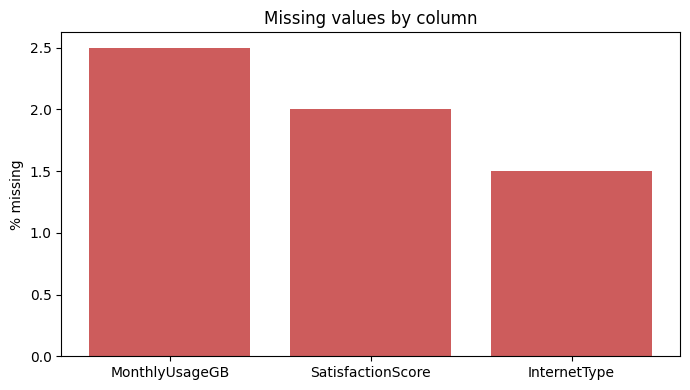

In [6]:
plt.figure(figsize=(7, 4))
plt.bar(missing.index, missing["missing_pct"], color="indianred")
plt.ylabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

### Descriptive statistics

In [7]:
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,3000.0,44.06,15.35,18.00,31.00,44.00,57.00,70.00
TenureMonths,3000.0,25.54,16.53,1.00,13.00,22.00,35.00,72.00
MonthlyUsageGB,2925.0,230.13,89.36,10.00,169.50,228.70,290.40,597.90
MonthlyChargeEGP,3000.0,487.35,118.45,142.40,398.99,485.00,574.57,866.99
NumServices,3000.0,3.52,1.71,1.00,2.00,4.00,5.00,6.00
SupportCalls6M,3000.0,2.21,1.50,0.00,1.00,2.00,3.00,9.00
LatePayments12M,3000.0,1.11,1.07,0.00,0.00,1.00,2.00,6.00
SatisfactionScore,2940.0,3.49,1.01,1.00,3.00,4.00,4.00,5.00
Future12MRevenueEGP,3000.0,5361.16,1479.87,1529.37,4330.79,5274.62,6314.50,11095.19


In [8]:
for col in cat_cols:
    print(df[col].value_counts(dropna=False), "\n")

Region
Cairo          983
Giza           597
Delta          539
Alexandria     469
Upper Egypt    412
Name: count, dtype: int64 

ContractType
Month-to-month    1680
One year           814
Two year           506
Name: count, dtype: int64 

InternetType
Fiber    1350
DSL       824
4G/5G     781
NaN        45
Name: count, dtype: int64 

PaperlessBilling
Yes    2110
No      890
Name: count, dtype: int64 

AutoPay
Yes    1684
No     1316
Name: count, dtype: int64 

Churn
No     2456
Yes     544
Name: count, dtype: int64 



### Churn distribution

In [9]:
churn_counts = df["Churn"].value_counts()
churn_pct = (df["Churn"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"count": churn_counts, "pct": churn_pct})

,count,pct
Churn,,
No,2456,81.87
Yes,544,18.13


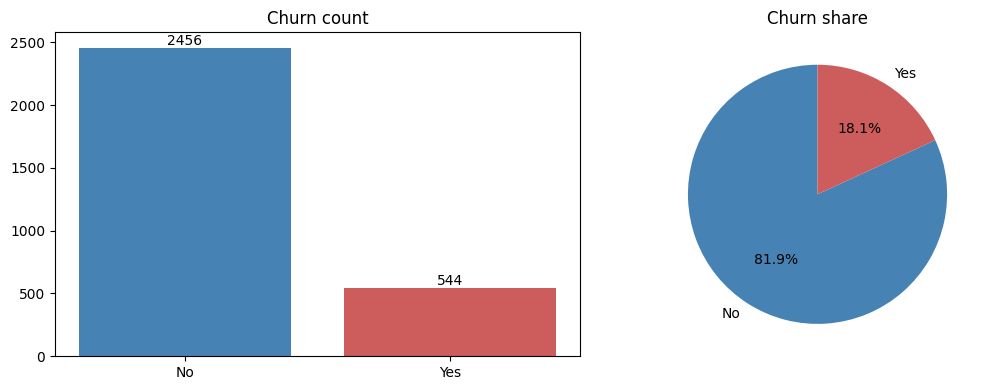

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(churn_counts.index, churn_counts.values, color=["steelblue", "indianred"])
ax[0].set_title("Churn count")
for i, v in enumerate(churn_counts.values):
    ax[0].text(i, v + 20, str(v), ha="center")

ax[1].pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
          colors=["steelblue", "indianred"], startangle=90)
ax[1].set_title("Churn share")

plt.tight_layout()
plt.show()

### Numerical distributions

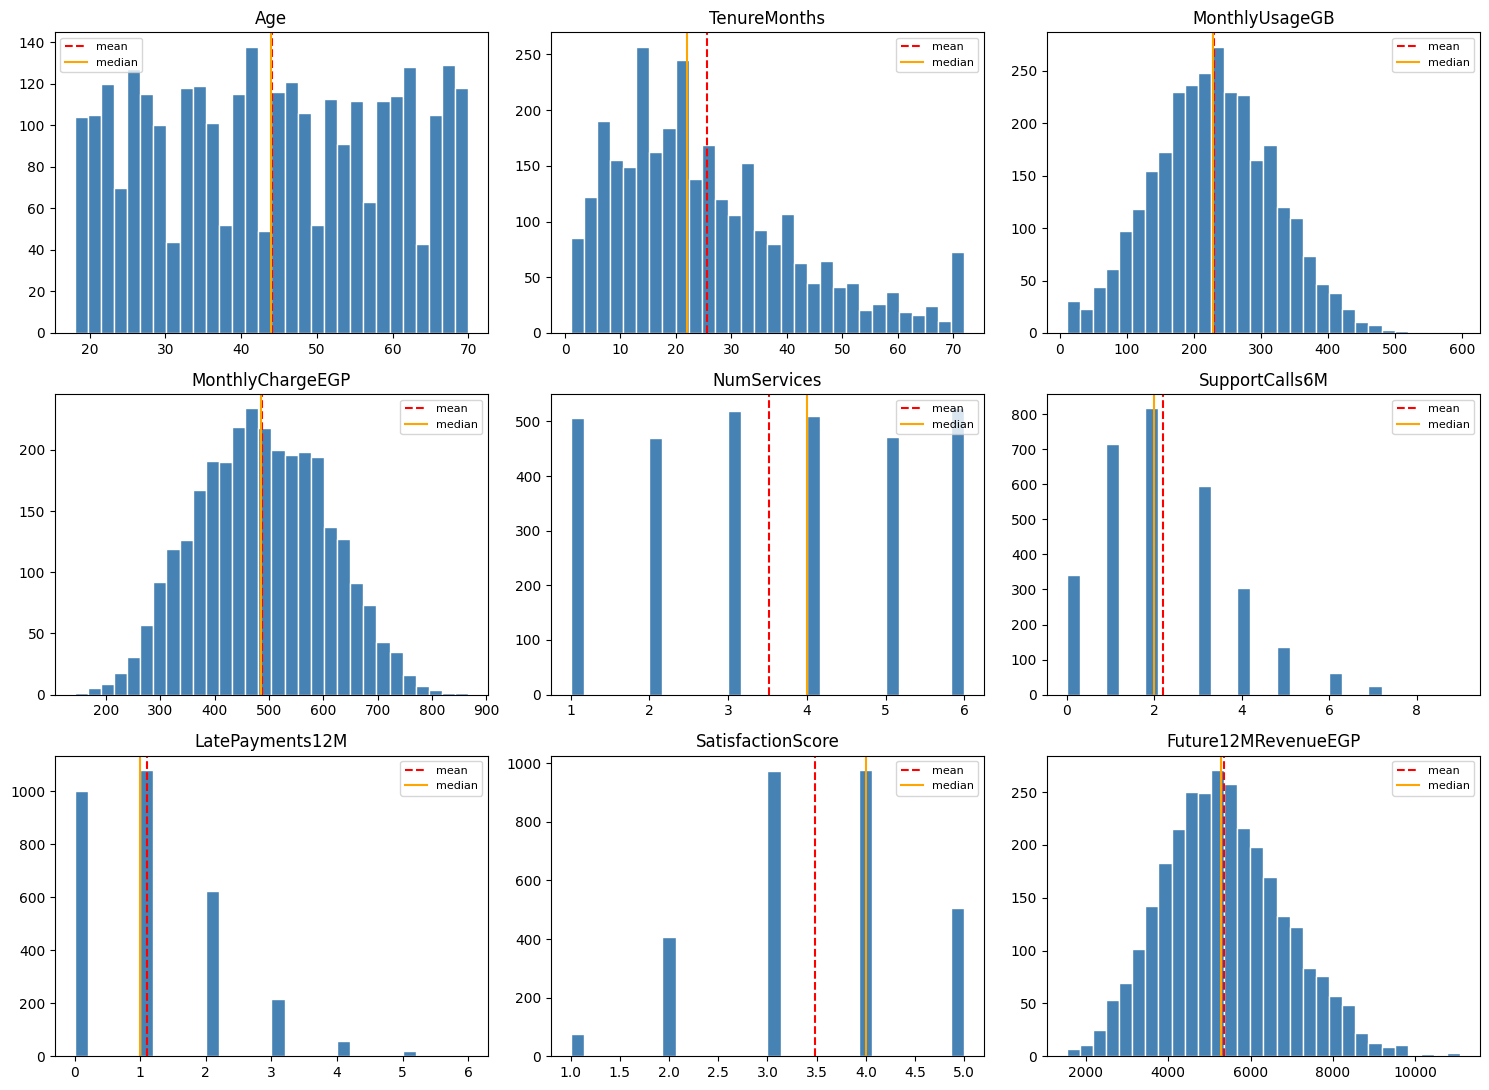

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color="steelblue", edgecolor="white")
    axes[i].axvline(data.mean(), color="red", linestyle="--", label="mean")
    axes[i].axvline(data.median(), color="orange", linestyle="-", label="median")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [12]:
df[num_cols].skew().round(2).sort_values(ascending=False)

LatePayments12M        1.00
TenureMonths           0.91
SupportCalls6M         0.72
Future12MRevenueEGP    0.33
MonthlyUsageGB         0.11
MonthlyChargeEGP       0.04
Age                    0.01
NumServices           -0.01
SatisfactionScore     -0.24
dtype: float64

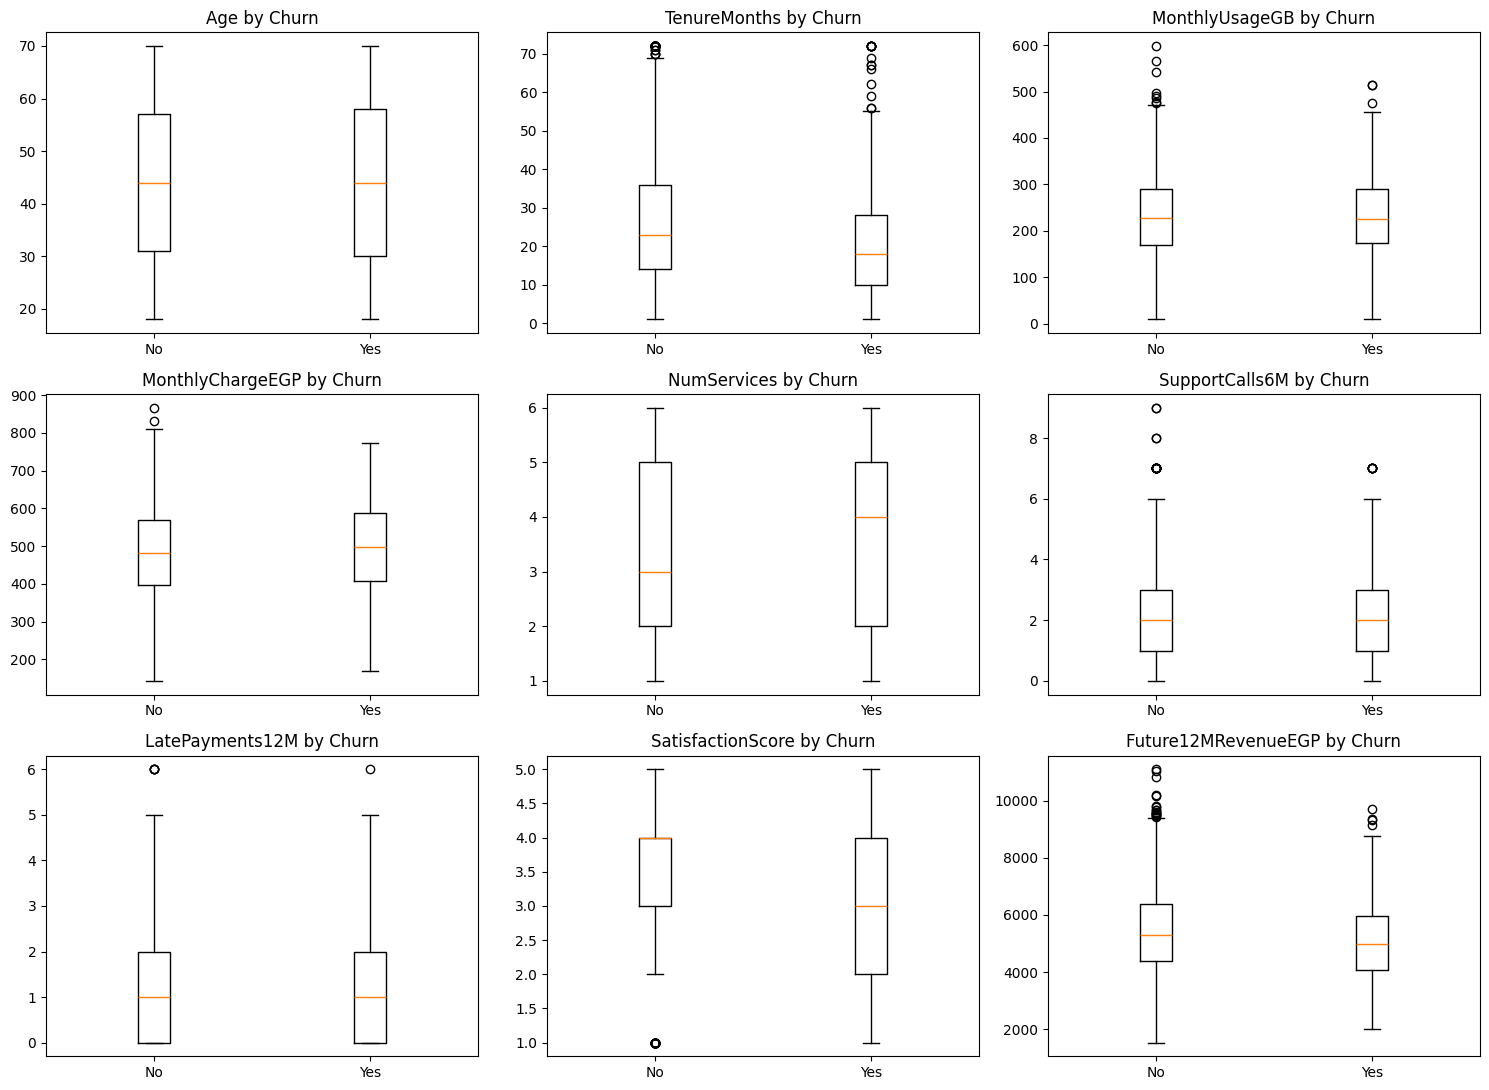

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    groups = [df.loc[df["Churn"] == g, col].dropna() for g in ["No", "Yes"]]
    axes[i].boxplot(groups, labels=["No", "Yes"])
    axes[i].set_title(col + " by Churn")

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [14]:
df.groupby("Churn")[num_cols].mean().T.round(2)

Churn,No,Yes
Age,44.11,43.83
TenureMonths,26.64,20.59
MonthlyUsageGB,230.42,228.85
MonthlyChargeEGP,485.35,496.36
NumServices,3.50,3.60
SupportCalls6M,2.15,2.44
LatePayments12M,1.07,1.29
SatisfactionScore,3.56,3.14
Future12MRevenueEGP,5428.11,5058.86


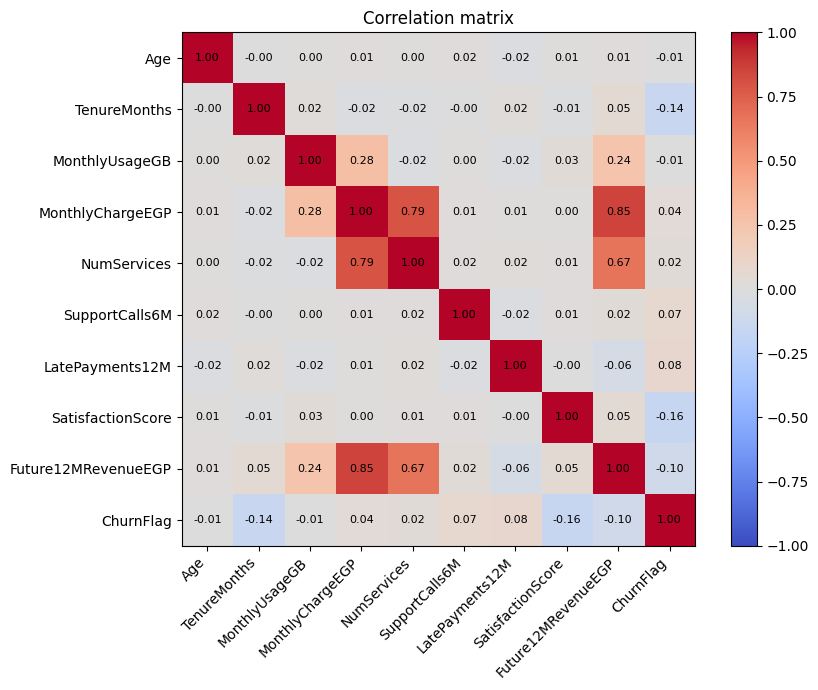

In [15]:
corr = df[num_cols].assign(ChurnFlag=(df["Churn"] == "Yes").astype(int)).corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, "{:.2f}".format(corr.iloc[i, j]), ha="center", va="center", fontsize=8)
fig.colorbar(im)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

### Churn by contract type and AutoPay

In [16]:
def churn_rate(col):
    t = pd.crosstab(df[col], df["Churn"])
    t["Total"] = t.sum(axis=1)
    t["ChurnRate%"] = (t["Yes"] / t["Total"] * 100).round(2)
    return t

contract_tbl = churn_rate("ContractType")
autopay_tbl = churn_rate("AutoPay")
contract_tbl

Churn,No,Yes,Total,ChurnRate%
ContractType,,,,
Month-to-month,1233,447,1680,26.61
One year,743,71,814,8.72
Two year,480,26,506,5.14


In [17]:
autopay_tbl

Churn,No,Yes,Total,ChurnRate%
AutoPay,,,,
No,1008,308,1316,23.40
Yes,1448,236,1684,14.01


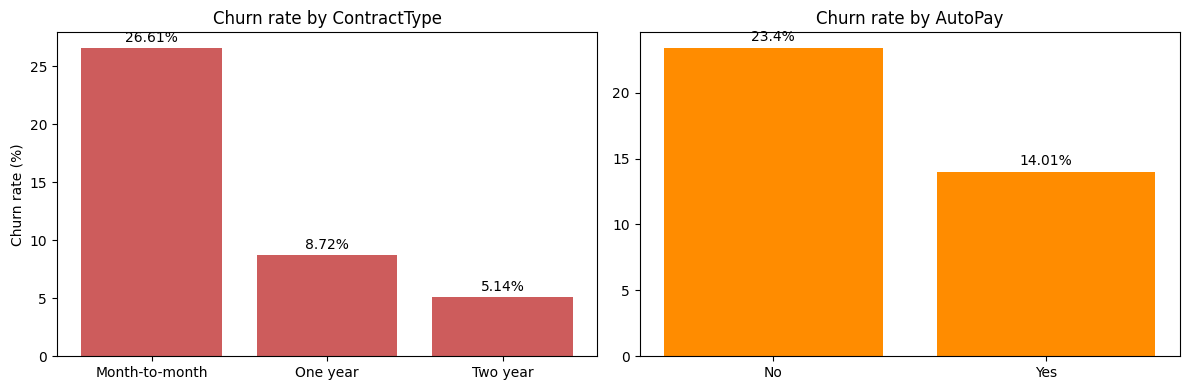

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(contract_tbl.index, contract_tbl["ChurnRate%"], color="indianred")
ax[0].set_title("Churn rate by ContractType")
ax[0].set_ylabel("Churn rate (%)")

ax[1].bar(autopay_tbl.index, autopay_tbl["ChurnRate%"], color="darkorange")
ax[1].set_title("Churn rate by AutoPay")

for a, t in zip(ax, [contract_tbl, autopay_tbl]):
    for i, v in enumerate(t["ChurnRate%"]):
        a.text(i, v + 0.5, "{}%".format(v), ha="center")

plt.tight_layout()
plt.show()

In [19]:
combo = df.pivot_table(index="ContractType", columns="AutoPay",
                       values="Churn", aggfunc=lambda s: (s == "Yes").mean() * 100).round(2)
combo

AutoPay,No,Yes
ContractType,,
Month-to-month,33.88,20.91
One year,11.76,6.35
Two year,7.24,3.51


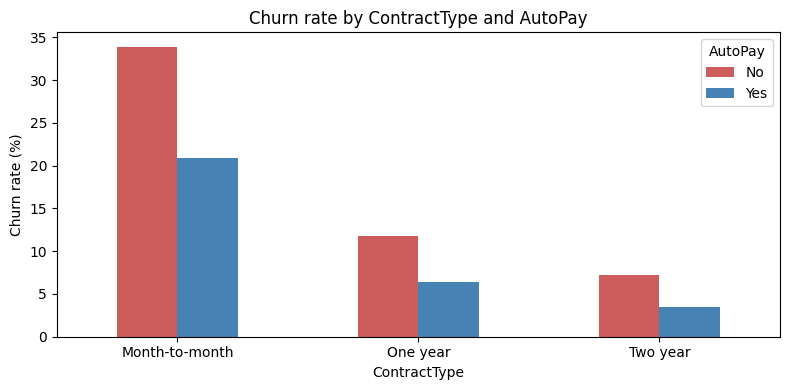

In [20]:
combo.plot(kind="bar", figsize=(8, 4), color=["indianred", "steelblue"])
plt.ylabel("Churn rate (%)")
plt.title("Churn rate by ContractType and AutoPay")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
for col in ["InternetType", "Region", "PaperlessBilling"]:
    print(churn_rate(col)[["Total", "ChurnRate%"]], "\n")

Churn         Total  ChurnRate%
InternetType                   
4G/5G           781       19.33
DSL             824       16.63
Fiber          1350       18.59 

Churn        Total  ChurnRate%
Region                        
Alexandria     469       18.76
Cairo          983       17.19
Delta          539       18.37
Giza           597       19.43
Upper Egypt    412       17.48 

Churn             Total  ChurnRate%
PaperlessBilling                   
No                  890       18.88
Yes                2110       17.82 



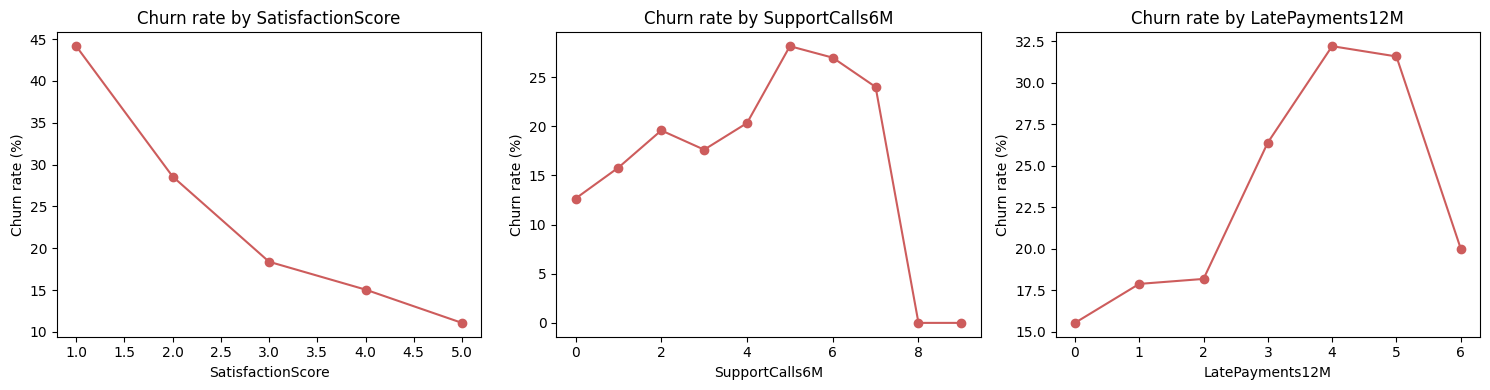

In [22]:
sat = df.groupby("SatisfactionScore")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(2)
calls = df.groupby("SupportCalls6M")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(2)
late = df.groupby("LatePayments12M")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, s, name in zip(ax, [sat, calls, late], ["SatisfactionScore", "SupportCalls6M", "LatePayments12M"]):
    a.plot(s.index, s.values, marker="o", color="indianred")
    a.set_title("Churn rate by " + name)
    a.set_xlabel(name)
    a.set_ylabel("Churn rate (%)")
plt.tight_layout()
plt.show()

In [23]:
tenure_bins = pd.cut(df["TenureMonths"], bins=[0, 6, 12, 24, 36, 48, 72])
df.groupby(tenure_bins)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(2)

TenureMonths
(0, 6]      25.45
(6, 12]     26.76
(12, 24]    19.57
(24, 36]    15.78
(36, 48]    11.67
(48, 72]     7.67
Name: Churn, dtype: float64

## EDA Summary

1. The dataset has **3,000 customers and 16 columns**, one row per customer, no duplicates. `CustomerID` is unique for every row.
2. Only three columns have missing values: `MonthlyUsageGB` (75, 2.5%), `SatisfactionScore` (60, 2%) and `InternetType` (45, 1.5%). Small enough to impute instead of dropping rows.
3. The target is **imbalanced**: about **18.1%** churn vs 81.9% stay.
4. **Contract type is the strongest categorical signal**: month-to-month customers churn at ~26.6%, compared with ~8.7% on one-year and ~5.1% on two-year contracts.
5. Customers **without AutoPay** churn at ~23.4% vs ~14.0% with AutoPay. The worst combination is month-to-month + no AutoPay.
6. Churners have **shorter tenure** (≈20.6 vs 26.6 months), **lower satisfaction** (≈3.1 vs 3.6), and slightly more support calls and late payments. Churn is highest in the first year.
7. Region, InternetType and PaperlessBilling show almost no difference in churn rate, so they are probably weak predictors.
8. The numerical features are on very different scales (e.g. `MonthlyChargeEGP` in hundreds, `NumServices` 1–6), so scaling will be needed for distance/gradient-based models.

## Questions

**1. Which column must be excluded because it is an identifier?**

`CustomerID`. It is unique per customer and carries no behavioral information, so a model could only memorize it, which doesn't generalize to new customers. We keep it only to join predictions back in the final Customer 360 table.

**2. Why should `Future12MRevenueEGP` not be used to predict current churn?**

It is target leakage. The value is about the *next 12 months*, which we don't know at prediction time, and it is directly affected by churn itself (a customer who leaves generates less future revenue). Using it would give unrealistically good scores in testing that disappear in production. It is the target of the regression task, not a feature.

**3. Is accuracy sufficient for churn prediction?**

No. With only ~18% churners, a model that predicts "No" for everyone already gets ~82% accuracy while catching zero churners. We should look at precision, recall, F1 and ROC-AUC for the churn class, plus the confusion matrix. Recall is usually important because missing a churner costs more than sending an unneeded retention offer.

**4. Which algorithms are sensitive to feature scaling?**

Algorithms that rely on distances, dot products or gradient/regularized optimization: **KNN**, **SVM**, **Logistic Regression** (especially with regularization), **Ridge/Lasso**, **K-Means**, **Agglomerative Clustering**, **DBSCAN** and **PCA**. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) and Naive Bayes are mostly not affected.